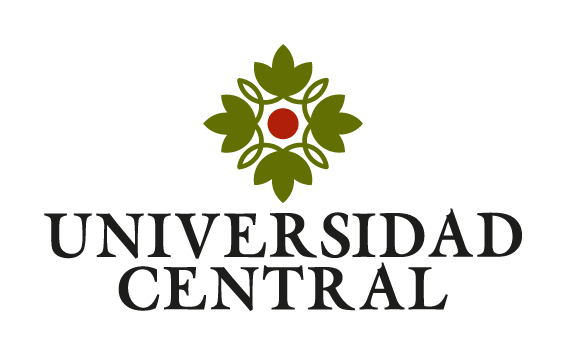

#MAESTRIA EN ANALITICA DE DATOS
---

PROCESAMIENTO DEL LENGUAJE NATURAL

Nombre: Oswaldo Salgado Gómez

Fecha: mayo 30 de 2026

Taller: Trabajo Final

# Etapa 3B — Evaluación de Calidad del Retrieval (v2)

Incorpora **métricas formales de calidad del retrieval** sobre el corpus ampliado (~50 autos). Consume el motor de la **Etapa 3** (`retriever_utils.Retriever`) sin modificarlo.

### Qué hace
1. **Gold set asistido por *pooling*** — relevancia **binaria** (relevante / no relevante). `POOL_K=15` por el corpus ampliado.
2. **Métricas estándar de IR** — Precision@k, Recall@k, MRR y nDCG@k contra el `Retriever` real, buscando sobre **todo el corpus**.
3. **Retrieval híbrido** — incluye consultas con filtro por `filename` (semántico + metadata).
4. **Reportes** — CSV agregado + por consulta en `Retrieval/Evaluacion/`, listos para el dashboard.



# HOJA DE RUTA A SEGUIR

0. Montar Google Drive
1. Instalar Dependencias (con pin de NumPy)
2. Instalar Librerías
3. Configuración de Rutas
4. Silenciar telemetría de ChromaDB antes de importar
5. Consultas de evaluación
6. Verificar que los filenames de los filtros existen en la colección
7. Construcción del gold set (pooling binario)
8. Cálculo de métricas
9. Exportar reportes
10. Visualización


# 0\. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#1\. Instalación de Dependencias

In [ ]:
!pip install chromadb transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.7 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-proto
    Found existing installation: opentelemetry-proto 1.38.0
    Uninstalling opentelemet

#2\. Instalar Librerias

In [ ]:
import os, sys, json, math
from datetime import datetime
import numpy as np
import pandas as pd
import math

#3\. Configuración de Rutas

In [ ]:
BASE_DIR      = "/content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final"
RETRIEVAL_DIR = os.path.join(BASE_DIR, "Retrieval")
CHROMA_DIR    = os.path.join(RETRIEVAL_DIR, "chroma_db")
EVAL_DIR      = os.path.join(RETRIEVAL_DIR, "Evaluacion")
GOLD_PATH     = os.path.join(EVAL_DIR, "gold_set.json")
os.makedirs(EVAL_DIR, exist_ok=True)

if RETRIEVAL_DIR not in sys.path:
    sys.path.insert(0, RETRIEVAL_DIR)

print("Rutas OK")
print("Gold set:", GOLD_PATH)
print("Salidas :", EVAL_DIR)

Rutas OK
Gold set: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/Evaluacion/gold_set.json
Salidas : /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/Evaluacion


# 4\. Silenciar telemetría de ChromaDB antes de importar

In [ ]:
os.environ["ANONYMIZED_TELEMETRY"] = "False"

from retriever_utils import Retriever

retriever = Retriever(chroma_dir=CHROMA_DIR)
n_chunks = retriever.collection.count()
print("Retriever cargado. Chunks en colección:", n_chunks)
print()

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/597M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/597M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/271 [00:00<?, ?it/s]

LongformerModel LOAD REPORT from: allenai/longformer-base-4096
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Retriever cargado. Chunks en colección: 1152



#5\. Consultas de evaluación

12 consultas globales (buscan en **todo el corpus**) + **3 consultas con filtro `filename`** que demuestran el **retrieval híbrido** (semántico + metadata).

**Sobre los filtros:** `Retriever.buscar()` acepta filtro por `filename` (no por `empresa`, que no quedó indexado en ChromaDB). El `filename` indexado lleva extensión **`.pdf`**. Se deben ajustar los nombres a autos que existan en el corpus.

In [ ]:
# Consultas GLOBALES (sin filtro): buscan en los ~50 autos.
CONSULTAS = [
    {"id": "Q01", "texto": "¿Cuáles son los fundamentos jurídicos que sustentan la apertura del procedimiento sancionatorio?"},
    {"id": "Q02", "texto": "¿Qué obligaciones de la licencia o del plan de manejo ambiental se presumen incumplidas?"},
    {"id": "Q03", "texto": "¿Qué hechos motivaron la apertura del procedimiento sancionatorio?"},
    {"id": "Q04", "texto": "¿Qué medidas preventivas o requerimientos se impusieron a la empresa?"},
    {"id": "Q05", "texto": "¿Cuál es el número de expediente, la empresa investigada y su NIT?"},
    {"id": "Q06", "texto": "¿Qué normas o actos administrativos se señalan como presuntamente infringidos?"},
    {"id": "Q07", "texto": "¿Qué relación tienen los hechos con el plan de manejo ambiental o las fichas del PMA?"},
    {"id": "Q08", "texto": "¿Se identifican afectaciones o riesgos a recursos hídricos, atmósfera, aire, fauna, hidrofauna, flora, suelo o comunidades?"},
    {"id": "Q09", "texto": "¿Qué actuaciones administrativas previas, autos o resoluciones de seguimiento se mencionan?"},
    {"id": "Q10", "texto": "¿Qué presuntas infracciones ambientales se le atribuyen al titular conforme al artículo 5 de la Ley 1333 de 2009?"},
    {"id": "Q11", "texto": "¿Cuáles son las consideraciones de la autoridad para iniciar la investigación sin indagación preliminar?"},
    {"id": "Q12", "texto": "¿El incumplimiento está relacionado con la ocurrencia o el reporte de contingencias ambientales?"},

    # ── CONSULTAS HÍBRIDAS (semántico + filtro por filename) ──
    # Demuestran el retrieval híbrido. Ajusta los filenames a autos reales de tu corpus.
    {"id": "Q13", "texto": "¿Qué hechos por contingencias y fugas de gas se describen?",
     "filtros": {"filename": "2839_1516_2024-03-20.pdf"}},
    {"id": "Q14", "texto": "¿Qué obligaciones de evaluación económica ambiental se incumplieron?",
     "filtros": {"filename": "2456_5935_2023-07-31.pdf"}},
    {"id": "Q15", "texto": "¿Qué contingencias de derrame y caída de soda cáustica se reportan?",
     "filtros": {"filename": "2152_5349_2022-07-13.pdf"}},
]
print(f"{len(CONSULTAS)} consultas ({sum(1 for c in CONSULTAS if c.get('filtros'))} con filtro híbrido).")

15 consultas (3 con filtro híbrido).


#6\. Verificar que los filenames de los filtros existen en la colección

Si una consulta híbrida devuelve 0 resultados, casi siempre es porque el `filename` del filtro no coincide con el indexado. Esta celda lo comprueba.

In [ ]:
# Comprobar que cada filename usado en filtros existe en ChromaDB
filtros_usados = [c["filtros"]["filename"] for c in CONSULTAS if c.get("filtros") and "filename" in c["filtros"]]
for fn in filtros_usados:
    res = retriever.collection.get(where={"filename": {"$eq": fn}}, limit=1)
    existe = len(res["ids"]) > 0
    print(("✓" if existe else "✗"), fn, "→", "encontrado" if existe else "NO está en la colección (ajusta el nombre)")

✓ 2839_1516_2024-03-20.pdf → encontrado
✓ 2456_5935_2023-07-31.pdf → encontrado
✓ 2152_5349_2022-07-13.pdf → encontrado


#7\. Construcción del gold set (*pooling* binario)

Para cada consulta se recuperan `POOL_K=15` candidatos y los calificas como **relevante (1)** o **no relevante (0)**.

**Regla simple:** *¿este fragmento me serviría para responder la consulta?* Sí → `1`. No, o solo lo menciona de pasada → `0`.

Comandos: `1`/`0` para calificar, `v` para ver el texto completo, `s` o Enter para no relevante (=0), `q` para abortar (lo etiquetado queda guardado).

Honestidad al etiquetar: algunos autos (p. ej. de apertura simple) **no contienen** medidas preventivas ni sanciones concretas. Si el chunk no responde se debe márcar `0` aunque trate del tema.

In [ ]:
POOL_K  = 15      # candidatos por consulta (subido por el corpus ampliado de ~50 autos)
SNIPPET = 300     # caracteres de vista previa

def _preview(txt, n=SNIPPET):
    txt = " ".join((txt or "").split())
    return txt[:n] + ("…" if len(txt) > n else "")

def etiquetar_consulta(consulta: dict, pool_k: int = POOL_K) -> dict:
    filtros = consulta.get("filtros") or {}
    cands = retriever.buscar(consulta["texto"], top_k=pool_k, **filtros)
    etiqueta_filtro = f"  [FILTRO: {filtros}]" if filtros else ""
    print("\n" + "="*92)
    print(f'[{consulta["id"]}] {consulta["texto"]}{etiqueta_filtro}')
    print("="*92)
    if not cands:
        print("  ⚠ 0 candidatos recuperados. Si hay filtro, revisa que el filename exista.")
    juicios = {}
    for idx, c in enumerate(cands, 1):
        md_ = c["metadata"]
        while True:
            print(f'\n  ({idx}/{len(cands)}) chunk_id={c["chunk_id"]}  sim={c["similitud"]:.3f}')
            print(f'      archivo : {md_.get("filename","")}')
            print(f'      numeral : {md_.get("numeral","")}  | tipo={md_.get("tipo_chunk","")}'
                  f'  | pág {md_.get("pagina_inicio","")}-{md_.get("pagina_fin","")}')
            print(f'      título  : {md_.get("titulo_bloque","")[:95]}')
            print(f'      texto   : {_preview(c["texto"])}')
            r = input("      relevante? [1=sí / 0=no] (v=ver, s=skip→0, q=abortar): ").strip().lower()
            if r == "v":
                print("\n      ───── TEXTO COMPLETO ─────")
                print("      " + (c["texto"] or "").replace("\n", "\n      "))
                continue
            if r == "q":
                raise KeyboardInterrupt("Etiquetado abortado por el usuario.")
            if r in ("s", "", "0"):
                juicios[c["chunk_id"]] = 0
                break
            if r == "1":
                juicios[c["chunk_id"]] = 1
                break
            print("      Entrada inválida. Usa 1, 0, v, s o q.")
    return {
        "id": consulta["id"],
        "texto": consulta["texto"],
        "filtros": filtros,
        "juicios": juicios,     # {chunk_id: 0|1}  binario
        "pool_k": pool_k,
    }

print("Funciones de etiquetado binario listas. POOL_K =", POOL_K)

Funciones de etiquetado binario listas. POOL_K = 15


In [ ]:
# Cargar gold set previo si existe (no re-etiquetar)
if os.path.exists(GOLD_PATH):
    with open(GOLD_PATH, encoding="utf-8") as f:
        gold_set = json.load(f)
    ids_hechas = {g["id"] for g in gold_set}
    print(f"Gold set existente: {len(gold_set)} consultas etiquetadas.")
else:
    gold_set, ids_hechas = [], set()
    print("No hay gold set previo. Se creará uno nuevo.")

No hay gold set previo. Se creará uno nuevo.


In [ ]:
# Etiquetar solo lo pendiente (re-ejecutable: retoma donde se quiedo el proceso)
pendientes = [c for c in CONSULTAS if c["id"] not in ids_hechas]
print(f"Pendientes: {len(pendientes)} de {len(CONSULTAS)}\n")

try:
    for consulta in pendientes:
        registro = etiquetar_consulta(consulta)
        gold_set.append(registro)
        ids_hechas.add(consulta["id"])
        with open(GOLD_PATH, "w", encoding="utf-8") as f:   # guardado incremental
            json.dump(gold_set, f, ensure_ascii=False, indent=2)
        print(f'  ✓ {consulta["id"]} guardado.')
except KeyboardInterrupt as e:
    print(f"\n⏸ {e}  (lo etiquetado quedó guardado)")

print(f"\nGold set actual: {len(gold_set)} consultas → {GOLD_PATH}")

Input ids are automatically padded to be a multiple of `config.attention_window`: 512


Pendientes: 15 de 15


[Q01] ¿Cuáles son los fundamentos jurídicos que sustentan la apertura del procedimiento sancionatorio?

  (1/15) chunk_id=AUTO_000589_2022-02-09_AUTO_000589_2022-02-09_blk_0009_txt_0  sim=0.990
      archivo : 2312_589_2022-02-09.pdf
      numeral : 1  | tipo=texto  | pág 3-3
      título  : El presente manejo de los residuos sólidos generados durante el desarrollo del proyecto, quedar
      texto   : El presente manejo de los residuos sólidos generados durante el desarrollo del proyecto, quedará sujeto al cumplimiento de las siguientes obligaciones:. (…)
      relevante? [1=sí / 0=no] (v=ver, s=skip→0, q=abortar): 1

  (2/15) chunk_id=AUTO_011096_2023-12-27_AUTO_011096_2023-12-27_blk_0005_txt_0  sim=0.989
      archivo : 2330_11096_2023-12-27.pdf
      numeral : 4.1  | tipo=texto  | pág 5-5
      título  : Análisis de los hechos
      texto   : Análisis de los hechos. A continuación, se procede hacer el análisis sobre los motivos de apertura de la investigación 

#8\. Cálculo de métricas

- **Precision@k** — fracción de los k recuperados que son relevantes.
- **Recall@k** — relevantes recuperados / relevantes etiquetados *(acotado al pool — ver nota).*
- **MRR** — 1/(posición del primer relevante).
- **nDCG@k** — ganancia descontada por posición (con relevancia binaria 0/1), normalizada.

Cada consulta se evalúa con su mismo filtro (si lo tiene), buscando como en producción.

In [ ]:
KS = [1, 3, 5, 10]  # valores de k a reportar

def dcg(rels):
    return sum((2**rel - 1) / math.log2(i + 2) for i, rel in enumerate(rels))

def ndcg_at_k(ranked_rels, ideal_rels, k):
    d = dcg(ranked_rels[:k])
    idcg = dcg(sorted(ideal_rels, reverse=True)[:k])
    return (d / idcg) if idcg > 0 else 0.0

def evaluar_consulta(registro, ks=KS):
    juicios = {cid: int(r) for cid, r in registro["juicios"].items()}
    relevantes = {cid for cid, r in juicios.items() if r == 1}   # binario
    n_rel = len(relevantes)

    filtros = registro.get("filtros") or {}
    resultados = retriever.buscar(registro["texto"], top_k=max(ks), **filtros)
    ranked_ids  = [c["chunk_id"] for c in resultados]
    ranked_rels = [juicios.get(cid, 0) for cid in ranked_ids]
    ideal_rels  = list(juicios.values())

    fila = {"id": registro["id"],
            "con_filtro": bool(filtros),
            "n_relevantes": n_rel,
            "n_recuperados": len(ranked_ids)}

    rr = 0.0
    for pos, cid in enumerate(ranked_ids, 1):
        if cid in relevantes:
            rr = 1.0 / pos
            break
    fila["MRR"] = rr

    for k in ks:
        topk = ranked_ids[:k]
        hits = sum(1 for cid in topk if cid in relevantes)
        fila[f"P@{k}"]    = hits / k if k else 0.0
        fila[f"R@{k}"]    = hits / n_rel if n_rel else 0.0
        fila[f"nDCG@{k}"] = ndcg_at_k(ranked_rels, ideal_rels, k)
    return fila

print("Funciones de métricas listas.")

Funciones de métricas listas.


In [ ]:
assert gold_set, "Gold set vacío. Etiqueta en la sección 3 primero."

filas = [evaluar_consulta(g) for g in gold_set]
df_por_consulta = pd.DataFrame(filas)

cols_fijas = ["id", "con_filtro", "n_relevantes", "n_recuperados", "MRR"]
cols_k = sorted([c for c in df_por_consulta.columns if c not in cols_fijas])
df_por_consulta = df_por_consulta[cols_fijas + cols_k]

sin_rel = df_por_consulta[df_por_consulta["n_relevantes"] == 0]["id"].tolist()
if sin_rel:
    print("⚠ Consultas sin relevantes (excluidas del promedio):", sin_rel)
df_validas = df_por_consulta[df_por_consulta["n_relevantes"] > 0]
df_por_consulta

# Guardar el reporte analítico en Excel o CSV dentro de la carpeta de evaluación
ruta_reporte = os.path.join(EVAL_DIR, "reporte_metricas_retrieval.csv")
df_por_consulta.to_csv(ruta_reporte, index=False, encoding="utf-8")
print(f"✓ Reporte detallado guardado con éxito en: {ruta_reporte}")

⚠ Consultas sin relevantes (excluidas del promedio): ['Q04', 'Q05', 'Q09']
✓ Reporte detallado guardado con éxito en: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/Evaluacion/reporte_metricas_retrieval.csv


In [ ]:
# ── MÓDULO OPCIONAL: Promedios Globales de Calidad ──
print("\n" + "="*50)
print("     MÉTRICAS RESUMIDAS DEL RETRIEVAL (PROMEDIO)")
print("="*50)
print(f"Mean Reciprocal Rank (MRR): {df_validas['MRR'].mean():.4f}")

for k in [1, 3, 5, 10]:
    if f"nDCG@{k}" in df_validas.columns:
        print(f"nDCG@{k:<2} : {df_validas[f'nDCG@{k}'].mean():.4f}  |  "
              f"P@{k:<2} : {df_validas[f'P@{k}'].mean():.4f}  |  "
              f"R@{k:<2} : {df_validas[f'R@{k}'].mean():.4f}")
print("="*50)


     MÉTRICAS RESUMIDAS DEL RETRIEVAL (PROMEDIO)
Mean Reciprocal Rank (MRR): 0.7917
nDCG@1  : 0.6667  |  P@1  : 0.6667  |  R@1  : 0.1347
nDCG@3  : 0.7160  |  P@3  : 0.6667  |  R@3  : 0.2588
nDCG@5  : 0.7133  |  P@5  : 0.6500  |  R@5  : 0.3610
nDCG@10 : 0.7451  |  P@10 : 0.6500  |  R@10 : 0.6518


In [ ]:
# Resumen agregado: global, y desglosado por tipo (con/sin filtro híbrido)
metricas = [c for c in df_validas.columns if c not in ("id","con_filtro","n_relevantes","n_recuperados")]

def resumen_de(df, etiqueta):
    if len(df) == 0:
        return None
    s = df[metricas].mean().round(4)
    s["_n_consultas"] = len(df)
    s.name = etiqueta
    return s

filas_resumen = [r for r in [
    resumen_de(df_validas, "TODAS"),
    resumen_de(df_validas[~df_validas["con_filtro"]], "Solo semánticas"),
    resumen_de(df_validas[df_validas["con_filtro"]], "Híbridas (filtro)"),
] if r is not None]

df_resumen = pd.DataFrame(filas_resumen)
print(f"Promedios sobre {len(df_validas)} consultas válidas\n")
df_resumen

Promedios sobre 12 consultas válidas



,MRR,P@1,P@10,P@3,P@5,R@1,R@10,R@3,R@5,nDCG@1,nDCG@10,nDCG@3,nDCG@5,_n_consultas
TODAS,0.7917,0.6667,0.6500,0.6667,0.6500,0.1347,0.6518,0.2588,0.3610,0.6667,0.7451,0.7160,0.7133,12.0
Solo semánticas,0.8333,0.7778,0.6556,0.6667,0.6444,0.1672,0.6341,0.2663,0.3607,0.7778,0.7641,0.7517,0.7427,9.0
Híbridas (filtro),0.6667,0.3333,0.6333,0.6667,0.6667,0.0370,0.7051,0.2365,0.3618,0.3333,0.6880,0.6089,0.6249,3.0


#9\. Exportar reportes

In [ ]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")

p_consulta = os.path.join(EVAL_DIR, f"metricas_por_consulta_{ts}.csv")
df_por_consulta.to_csv(p_consulta, index=False, encoding="utf-8-sig")
df_por_consulta.to_csv(os.path.join(EVAL_DIR, "last_metricas_por_consulta.csv"), index=False, encoding="utf-8-sig")

p_resumen = os.path.join(EVAL_DIR, f"metricas_resumen_{ts}.csv")
df_resumen.to_csv(os.path.join(EVAL_DIR, "last_metricas_resumen.csv"), encoding="utf-8-sig")
df_resumen.to_csv(p_resumen, encoding="utf-8-sig")

meta = {
    "timestamp": ts,
    "n_chunks_corpus": int(retriever.collection.count()),
    "n_consultas_total": len(df_por_consulta),
    "n_consultas_validas": int((df_por_consulta["n_relevantes"] > 0).sum()),
    "n_consultas_hibridas": int(df_por_consulta["con_filtro"].sum()),
    "relevancia": "binaria (0/1)",
    "ks": KS,
    "pool_k": POOL_K,
    "coleccion": "autos_anla_longformer",
    "metrica_distancia": "coseno",
    "nota_recall": "Recall acotado al pooling; subestima el universo real de relevantes en corpus de ~50 autos.",
}
with open(os.path.join(EVAL_DIR, f"eval_meta_{ts}.json"), "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("✓ Reportes en:", EVAL_DIR)
print("  - last_metricas_resumen.csv / last_metricas_por_consulta.csv")
print("  -", os.path.basename(p_resumen))

✓ Reportes en: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/Evaluacion
  - last_metricas_resumen.csv / last_metricas_por_consulta.csv
  - metricas_resumen_20260526_215930.csv


#10\. Visualización

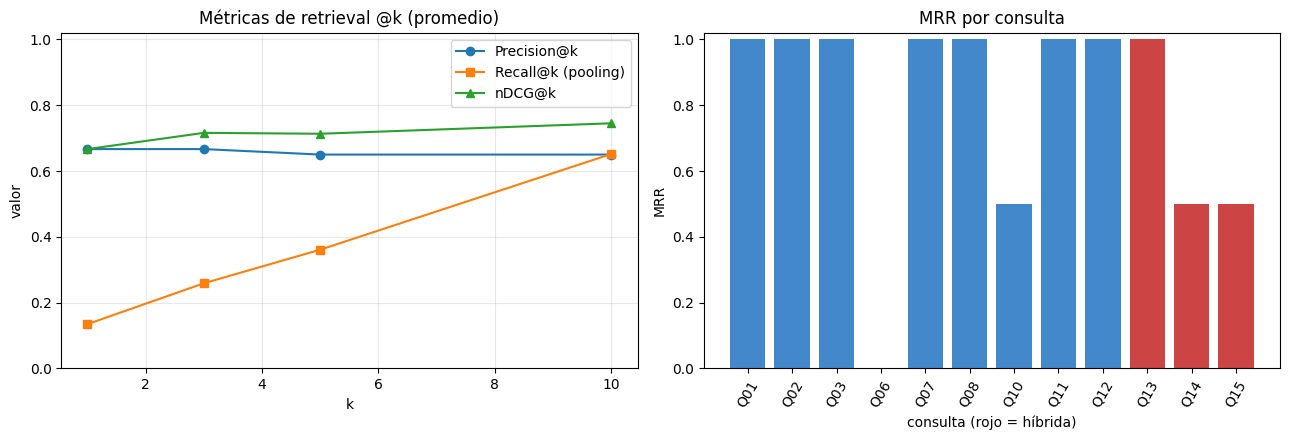

✓ Figura: /content/drive/MyDrive/4_Semestre_4/PLN/Trabajo final/Retrieval/Evaluacion/metricas_retrieval.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ks = KS
axes[0].plot(ks, [df_validas[f"P@{k}"].mean() for k in ks], "o-", label="Precision@k")
axes[0].plot(ks, [df_validas[f"R@{k}"].mean() for k in ks], "s-", label="Recall@k (pooling)")
axes[0].plot(ks, [df_validas[f"nDCG@{k}"].mean() for k in ks], "^-", label="nDCG@k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("valor"); axes[0].set_ylim(0, 1.02)
axes[0].set_title("Métricas de retrieval @k (promedio)"); axes[0].legend(); axes[0].grid(alpha=.3)

colores = ["#c44" if cf else "#48c" for cf in df_validas["con_filtro"]]
axes[1].bar(df_validas["id"], df_validas["MRR"], color=colores)
axes[1].set_xlabel("consulta (rojo = híbrida)"); axes[1].set_ylabel("MRR"); axes[1].set_ylim(0, 1.02)
axes[1].set_title("MRR por consulta"); axes[1].tick_params(axis="x", rotation=60)

plt.tight_layout()
fig_path = os.path.join(EVAL_DIR, "metricas_retrieval.png")
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print("✓ Figura:", fig_path)

---

**Limitación:** el Recall@k está acotado al *pooling* (relevantes etiquetados). Con ~50 autos, el universo real de chunks relevantes excede ampliamente el conjunto etiquetado, por lo que el Recall@k **subestima** el universo verdadero y debe leerse como recall sobre el conjunto evaluado, no como recall absoluto.
